What You're Aiming For
The objective of this checkpoint is to analyze the 'Climate change in Africa' dataset by visualizing temperature fluctuations across five African countries from 1980 to 2023, focusing on specific tasks like plotting temperature trends, comparing histograms of temperature distributions, and determining the most effective chart for representing average temperatures per country.


Instructions
In this checkpoint, we are going to work on the 'Climate change in Africa' dataset that was provided by the U.S global change research program.

Dataset description : This dataset contains historical data about the daily min, max and average temperature fluctuation in 5 African countries (Egypt, Tunisia, Cameroon, Senegal, Angola) between 1980 and 2023.

➡️ Dataset link

https://i.imgur.com/w2czdso.jpg

Load the dataset into a data frame using Python.
Clean the data as needed.
Plot a line chart to show the average temperature fluctuations in Tunisia and Cameroon. Interpret the results.
Zoom in to only include data between 1980 and 2005, try to customize the axes labels.
Create Histograms to show temperature distribution in Senegal between [1980,2000] and [2000,2023] (in the same figure). Describe the obtained results.
Select the best chart to show the Average temperature per country.
Make your own questions about the dataset and try to answer them using the appropriate visuals.
 
Note: Feel free to choose the visualization library (e.g., Matplotlib, Seaborn, Plotly) that best suits your style and the requirements of the tasks listed below.

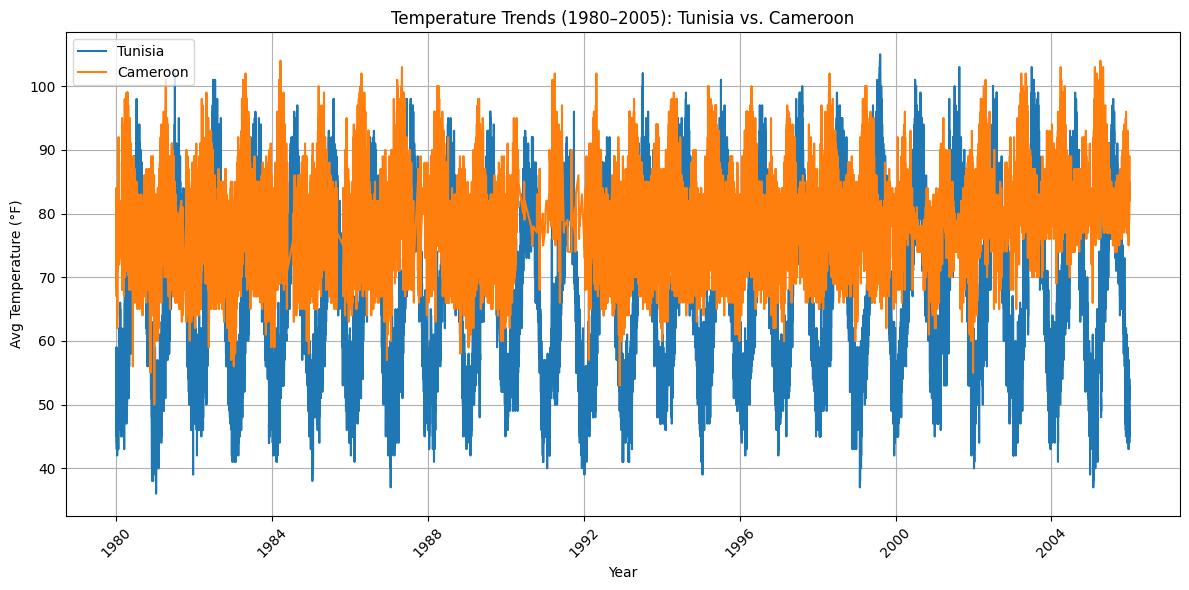

In [32]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

# Loading the data
data = pd.read_csv('Africa_climate_change.csv')

# Converting the 'DATE' column to datetime format while extracting the year
data['DATE'] = pd.to_datetime(data['DATE'].str[:8], format='%Y%m%d')

# Extracting the year from the 'DATE' column
data['Year'] = data['DATE'].dt.year


data['TAVG'] = data['TAVG'].fillna(data['TAVG'].mean())  # Fill missing values with the mean
data['TMAX'] = data['TMAX'].fillna(data['TMAX'].mean())  # Fill missing values with the mean
data['TMIN'] = data['TMIN'].fillna(data['TMIN'].mean())  # Fill missing values with the mean

# Zoom in on 1980–2005 and customize the axes
plt.figure(figsize=(12,6))
for country in ['Tunisia', 'Cameroon']:
    subset = data[(data['COUNTRY'] == country) & (data['Year'] <= 2005)]
    plt.plot(subset['DATE'], subset['TAVG'], label=country)
plt.title('Temperature Trends (1980–2005): Tunisia vs. Cameroon')
plt.xlabel('Year')
plt.ylabel('Avg Temperature (°F)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)  
plt.tight_layout()
plt.show()


In [ ]:
# Creating an histogram to show temperature distribution in Senegal between [1980,2000] and [2000, 2003] in the same figure 
plt.figure(figsize=(12,6))
for year_range in [(1980, 2000), (2000, 2023)]:
    subset = data[(data['COUNTRY'] == 'Senegal') & (data['Year'] >= year_range[0]) & (data['Year'] < year_range[1])]
    plt.hist(subset['TAVG'], bins=20, alpha=0.5, label=f'{year_range[0]}-{year_range[1]}')
plt.title('Temperature Distribution in Senegal')
plt.xlabel('Avg Temperature (°F)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Sengeal has likely experienced both a slight warming and increased daily temperature variability between 2000 and 2003 compared to the previous two decades; a possible symptom of global climate change

C:\Users\CASTOLO\AppData\Local\Temp\ipykernel_18912\771324845.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_temp_country, x='COUNTRY', y='TAVG',  palette='coolwarm')


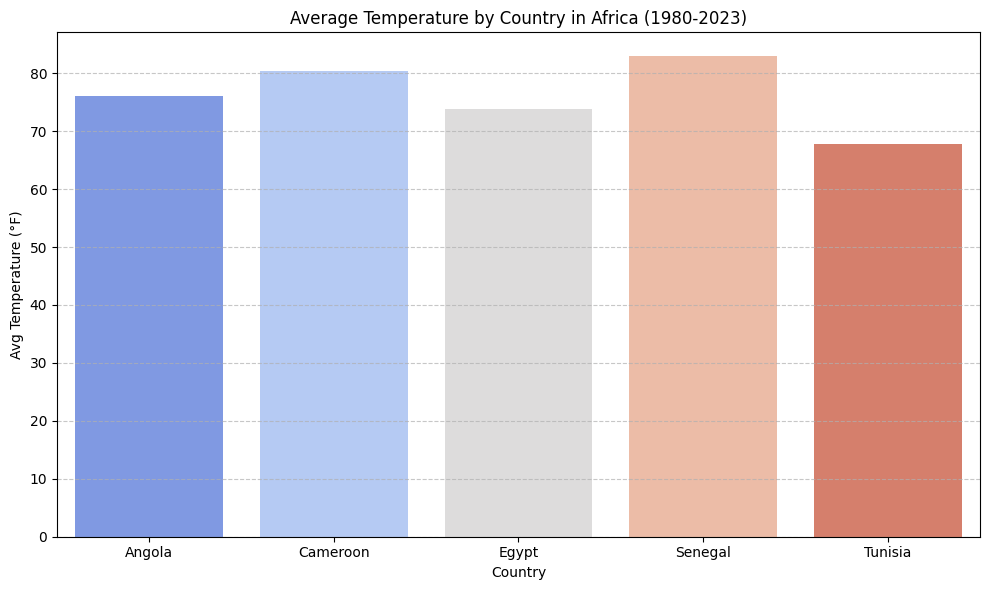

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

avg_temp_country = data.groupby('COUNTRY')['TAVG'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_temp_country, x='COUNTRY', y='TAVG',  palette='coolwarm')
plt.title('Average Temperature by Country in Africa (1980-2023)')
plt.xlabel('Country')
plt.ylabel('Avg Temperature (°F)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()